# Poverty Map (Open Street Map)

In [ ]:
### NODES (populated places): 
### We collected all nodes in OpenStreetMap that have one of the following tags: 
### ‘city’, ‘town’, ‘village’, ‘hamlet’, or ‘isolated_dwelling’.

In [ ]:
### ROADS: 
### We define roads as 'ways' in OpenStreetMap that have one of the following tags: 'primary', 'primary_link', 'secondary', 'secondary_link', 'tertiary', 'tertiary_link', 'trunk', 'trunk_link', 'motorway'.
### Also collect the surface types of roads to distinguish paved and unpaved roads.

In [ ]:
### JUNCTIONS:
### Our definition of junction is a node in OpenStreetMap where two or more ways cross, or 
### three or more ways begin. This definition includes nodes that don’t count as a typical road
### intersection, such as a road forking to two parallel trunk roads and a link to an overpass. We count
### them as junctions since they reflect a similar concept of man-made structure complexity to a road
### intersection.

In [ ]:
### 24 POIs
### bar, cafe, fast food, pub, college, kindergarten, library, school,
### university, bus station, atm, bank, clinic, dentist, 
### hospital, pharmacy, veterinary, cinema, community centre, 
### courthouse, embassy, marketplace, police, townhall.

## Setup

### Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
!ln -s /content/drive/MyDrive/Colab\ Notebooks/SES-Inference /mydrive

Mounted at /content/drive


### Dependencies

In [ ]:
!pip install OSMPythonTools
!pip install geopandas
!pip install pyshp

In [3]:
from glob import glob
import pandas as pd

import sys
sys.path.append('/mydrive/libs/')
%set_env PYTHONPATH=/env/python:/mydrive/libs/

%load_ext autoreload
%autoreload 2

from maps.geoviz import GeoViz
from maps.osm import OSM
from utils import ios

env: PYTHONPATH=/env/python:/mydrive/libs/


In [17]:
CACHE_DIR = '/mydrive/data/Uganda/cache/OSM/'
!ls $CACHE_DIR | wc -lc

  33395 1672017


## Data

### Survey (DHS)

In [6]:
fn_dhs = '/mydrive/data/Uganda/results/DHS2016_MIS2018_iwi_cluster.csv'

In [7]:
df_dhs = ios.load_csv(fn_dhs, index_col=0)
df_dhs.head()

,DHSCC,DHSYEAR,DHSCLUST,URBAN_RURA,LATNUM,LONGNUM,SOURCE,ALT_GPS,ALT_DEM,DATUM,mean_iwi,SES
0,UG,2016,1,1,0.320188,32.568206,GPS,9999.0,1197.0,WGS84,43.300000,rich
1,UG,2016,2,1,0.340653,32.593627,GPS,9999.0,1179.0,WGS84,24.967857,rich
2,UG,2016,3,1,0.313103,32.566556,GPS,9999.0,1189.0,WGS84,34.732000,rich
3,UG,2016,4,1,0.353368,32.558144,GPS,9999.0,1181.0,WGS84,36.060714,rich
4,UG,2016,5,1,0.367388,32.594357,GPS,9999.0,1226.0,WGS84,44.857692,rich


In [8]:
places = df_dhs[['LATNUM','LONGNUM']].to_records() #id,lat,lon
len(places)

1001

### OSM Features

* The total length of roads
* distance to the closest road
* number of junctions
* distance to the closest junctions
* total building area
* the number of buildings for each 1 square-mile populated area. 
* the number of and distance to 24 locations of interest such as schools, hospitals, and markets.

#### Example

In [11]:
osm = OSM()
osm.get_features(places[5:6], fn=None, overwrite=True, cache_dir=CACHE_DIR)

100%|██████████| 1/1 [00:03<00:00,  3.03s/it]


In [12]:
osm.features.head()

,id,lat,lon,total_length_roads,distance_closest_road,num_junctions,distance_closest_junction,total_building_area,num_buildings,bar,bar_dist,cafe,cafe_dist,fast_food,fast_food_dist,pub,pub_dist,college,college_dist,kindergarten,kindergarten_dist,library,library_dist,school,school_dist,university,university_dist,bus_station,bus_station_dist,atm,atm_dist,bank,bank_dist,clinic,clinic_dist,dentist,dentist_dist,hospital,hospital_dist,pharmacy,pharmacy_dist,veterinari,veterinari_dist,cinema,cinema_dist,community_centre,community_centre_dist,courthouse,courthouse_dist,embassy,embassy_dist,marketplace,marketplace_dist,police,police_dist,townhall,townhall_dist
0,5,0.358632,32.565558,18209.00972,357.29011,27,452.101253,439934.602897,8160,1,862.029232,1,891.123773,1,732.110958,0,0,0,0,3,290.754977,0,0,68,62.204351,0,0,2,778.262835,2,640.032366,8,358.553668,21,317.086527,0,0,0,0,11,425.861952,0,0,0,0,9,507.550823,0,0,0,0,1,892.718801,0,0,0,0


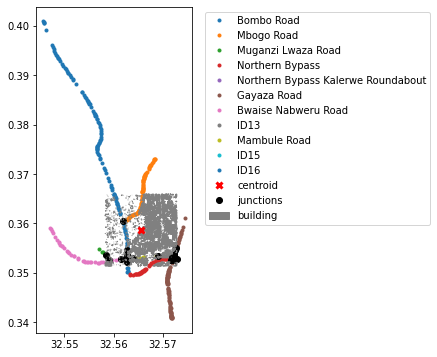

In [13]:
for i,row in osm.features.iterrows():
  GeoViz.plot_multiple_coords(osm.roads[i], row.lat, row.lon, osm.junctions[i], osm.buildings[i])

#### All-in-one

In [15]:
fn_osm = '/mydrive/data/Uganda/results/DHS2016_MIS2018_OSM.csv'
osm = OSM()
osm.get_features(places, fn=None, overwrite=True, cache_dir=CACHE_DIR)

100%|██████████| 1001/1001 [15:09<00:00,  1.10it/s]
